In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # Import StandardScaler to standardize features with mean 0 and standard deviation 1
from imblearn.over_sampling import RandomOverSampler # to balance the dataset by oversampling the minority class ensuring the model learns all classes more equally.

# MAGIC Gamma Telescope Dataset: Gamma vs Hadron Classification

In [ ]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("magic04.data", names=cols) #read and make name for colum
df.head() # show fist 5 rows
#df.iloc[19014, 10] #acces to row 19015 and colum 11

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
df["class"].unique() # show diferent values without repetiton

array(['g', 'h'], dtype=object)

In [ ]:
df["class"] = (df["class"] == "g").astype(int) #change "g" to 1 and "h" to 0

In [ ]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


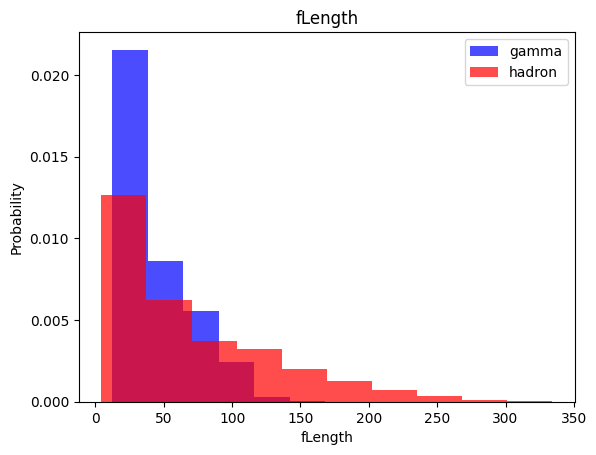

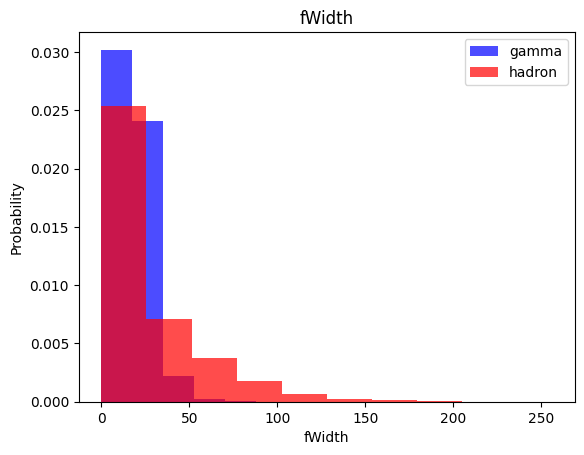

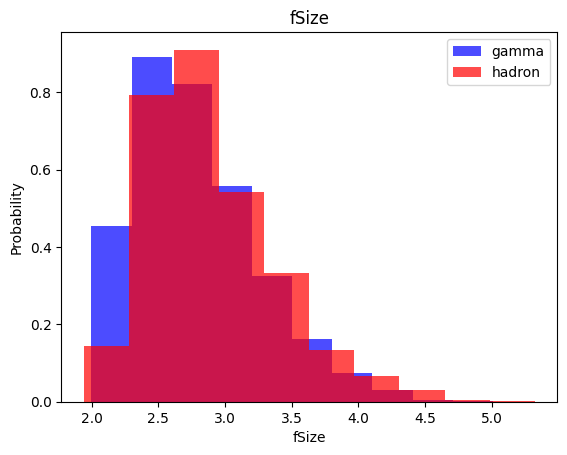

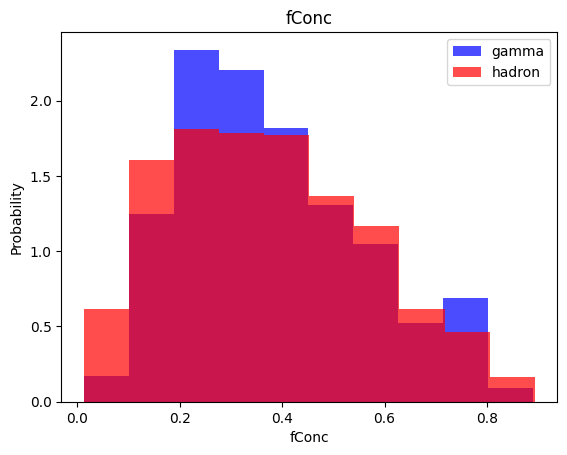

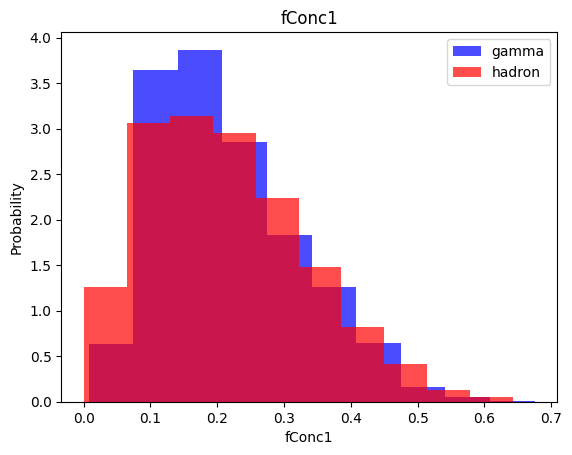

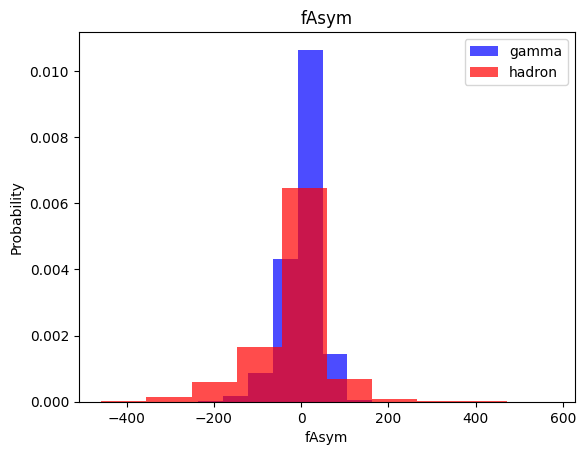

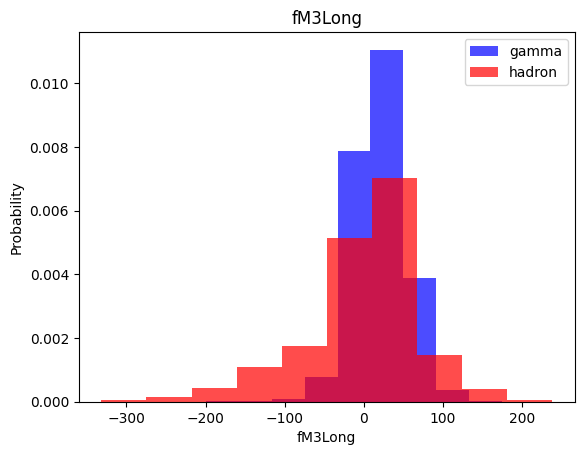

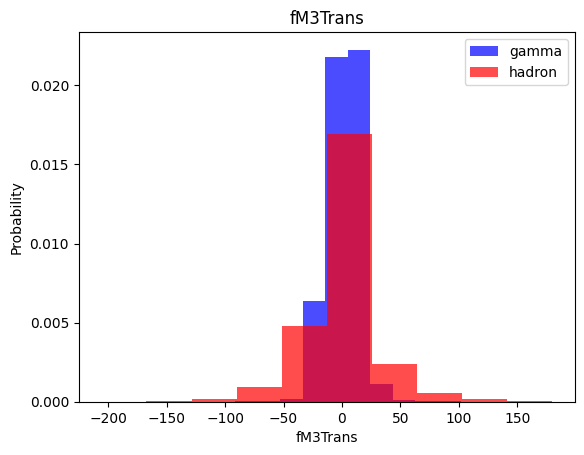

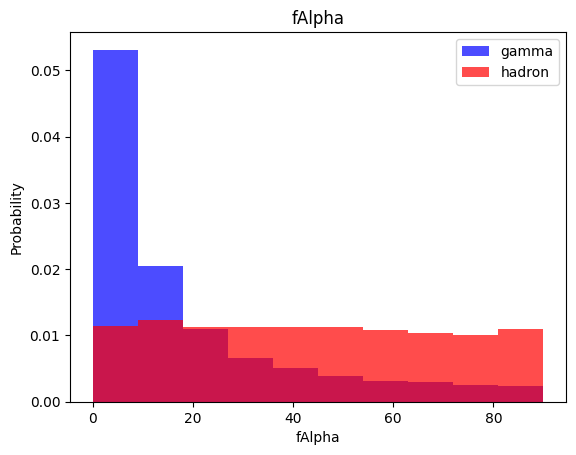

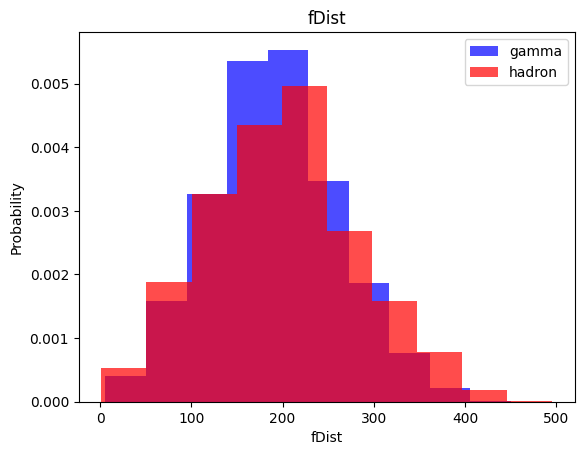

In [ ]:
for label in cols[:-1]:  #just see what happened in data
  plt.hist(df[df["class"]==1][label], color='blue', label='gamma', alpha=0.7, density=True)
  plt.hist(df[df["class"]==0][label], color='red', label='hadron', alpha=0.7, density=True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

# Train,   validation,   test datasets

In [ ]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))]) # Shuffle the dataset and split it into 60% train, 20% validation, and 20% test

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
def scale_dataset(datafarme, oversample=False):
  x = datafarme[datafarme.columns[:-1]].values
  y = datafarme[datafarme.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x) # Scale features to have a mean of 0 and a standard deviation of 1

  if oversample: # if our different labels like g, h had 900 and 100 samples we can just make oversample = True and with that method balance our data
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x, y)

  data = np.hstack((x, np.reshape(y, (-1,1))))

  return data, x, y

In [ ]:
train, x_train, y_train = scale_dataset(train, oversample=True)
valid, x_valid, y_valid = scale_dataset(valid, oversample=False)
test, x_test, y_test = scale_dataset(test, oversample=False)

In [ ]:
print(sum(y_train == 1), sum(y_train == 0)) #see it's worked

7383 7383


# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn_model.predict(x_test)

In [ ]:
print(y_pred , y_test) #look our KNN model train with x_train and y_train as data and label after that predict y_pred with x_test

[1 0 0 ... 1 1 1] [1 1 0 ... 1 1 1]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.73      0.73      1324
           1       0.86      0.86      0.86      2480

    accuracy                           0.82      3804
   macro avg       0.80      0.80      0.80      3804
weighted avg       0.82      0.82      0.82      3804



# **Naive Bayes**

## $$
P(C_i \mid x_1, x_2, x_3, \ldots, x_n)
=
\frac{
P(x_1, x_2, x_3, \ldots, x_n \mid C_i)\,P(C_i)
}{
P(x_1, x_2, x_3, \ldots, x_n)
}
$$

$$
P(x_1,x_2,\ldots,x_n \mid C_k)
=
\prod_{i=1}^{n} P(x_i \mid C_k)
$$

1.
$$
P(C_i \mid X)
=
\frac{P(X \mid C_i)\,P(C_i)}{P(X)}
$$
→ Bayes’ theorem: expresses posterior probability using likelihood and prior

---

2.
$$
P(C_i \mid X)
\propto
P(X \mid C_i)\,P(C_i)
$$
→ Since P(X) is constant for all classes, it is ignored for comparison

---

3.
$$
P(X \mid C_i)
=
\prod_{j=1}^{n} P(x_j \mid C_i)
$$
→ Naive assumption: features are conditionally independent given the class

---

4.
$$
\hat{C}
=
\arg\max_{C_i}
P(C_i)\prod_{j=1}^{n} P(x_j \mid C_i)
$$
→ Compute prior × likelihood for each class and select the class with maximum value

---

5.
$$
\hat{C}
=
\arg\max_{C_i}
P(C_i \mid x_1,x_2,\ldots,x_n)
$$
→ Final decision rule: choose the class with the highest posterior probability

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model = GaussianNB()
nb_model = nb_model.fit(x_train, y_train)

In [ ]:
y_pred = nb_model.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.42      0.53      1324
           1       0.75      0.91      0.82      2480

    accuracy                           0.74      3804
   macro avg       0.73      0.66      0.67      3804
weighted avg       0.73      0.74      0.72      3804



# **Logistic regression**

### Logistic Regression (Summary)

Logistic Regression is a classification model that estimates the probability of a binary outcome (0 or 1).

It computes a linear function:
$$
z = mx + b
$$

Then applies the sigmoid function:
$$
p = \frac{1}{1 + e^{-z}} = \sigma(z)
$$

Decision rule:
$$
p \ge 0.5 \Rightarrow \text{class } 1
$$
$$
p < 0.5 \Rightarrow \text{class } 0
$$

### Intuition
It is a linear model that outputs probabilities using the sigmoid function.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(x_train, y_train)

In [ ]:
y_pred = lg_model.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70      1324
           1       0.84      0.83      0.84      2480

    accuracy                           0.79      3804
   macro avg       0.77      0.77      0.77      3804
weighted avg       0.79      0.79      0.79      3804



# SUPPORT VECTOR MACHINES **(SVM)**

# Support Vector Machine (SVM)

## Training Data

Given

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n},
$$

where

$$
x_i\in\mathbb{R}^d,\qquad
y_i\in\{-1,+1\}.
$$

The decision hyperplane is

$$
w^Tx+b=0.
$$

---

## Margin

The signed distance of a sample to the hyperplane is

$$
\frac{y_i(w^Tx_i+b)}{\|w\|}.
$$

The margin is

$$
\boxed{\frac{2}{\|w\|}}.
$$

Maximizing the margin is equivalent to minimizing

$$
\frac{1}{2}\|w\|^2.
$$

---

## Hard-Margin Optimization

$$
\begin{aligned}
\min_{w,b}\quad&
\frac12\|w\|^2\\
\text{s.t.}\quad&
y_i(w^Tx_i+b)\ge1.
\end{aligned}
$$

---

## Lagrangian

$$
L(w,b,\alpha)
=
\frac12\|w\|^2
-
\sum_i
\alpha_i
\left(y_i(w^Tx_i+b)-1\right),
$$

where

$$
\alpha_i\ge0.
$$

From the KKT conditions,

$$
w=\sum_i\alpha_i y_i x_i,
$$

and

$$
\sum_i\alpha_i y_i=0.
$$

---

## Dual Problem

$$
\max_{\alpha}
\sum_i\alpha_i
-
\frac12
\sum_{i,j}
\alpha_i\alpha_j
y_i y_j
x_i^Tx_j,
$$

subject to

$$
\alpha_i\ge0,\qquad
\sum_i\alpha_i y_i=0.
$$

Only samples with

$$
\alpha_i>0
$$

are **support vectors**.

---

## Decision Function

$$
f(x)=w^Tx+b,
$$

or equivalently,

$$
\hat y=\operatorname{sign}(f(x)).
$$

---

## Soft Margin

$$
\begin{aligned}
\min_{w,b,\xi}\quad&
\frac12\|w\|^2
+
C\sum_i\xi_i\\
\text{s.t.}\quad&
y_i(w^Tx_i+b)\ge1-\xi_i,\\
&
\xi_i\ge0.
\end{aligned}
$$

---

## Kernel Trick

Instead of using

$$
\phi(x),
$$

compute

$$
K(x_i,x_j)=\phi(x_i)^T\phi(x_j).
$$

Decision function:

$$
f(x)
=
\sum_i
\alpha_i y_i
K(x_i,x)
+b.
$$

Common kernels:

- Linear:
  $$
  K(x,z)=x^Tz
  $$

- Polynomial:
  $$
  K(x,z)=(x^Tz+c)^d
  $$

- RBF:
  $$
  K(x,z)=\exp(-\gamma\|x-z\|^2)
  $$

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC()
svm_model = svm_model.fit(x_train, y_train)

In [ ]:
y_pred = svm_model.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1324
           1       0.89      0.90      0.90      2480

    accuracy                           0.87      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.87      0.87      0.87      3804



# **NN**

# Neural Network (NN)

## Training Data

Given

$$
\mathcal{D}
=
\{(x_i,y_i)\}_{i=1}^{n},
$$

where

$$
x_i\in\mathbb{R}^{d},
\qquad
y_i\in\mathbb{R}^{k}.
$$

For binary classification,

$$
y_i\in\{0,1\}.
$$

---

## Network Architecture

A neural network consists of

$$
\text{Input}
\rightarrow
\text{Hidden Layer(s)}
\rightarrow
\text{Output}.
$$

Each neuron computes

$$
z
=
Wx+b,
$$

where

- \(W\): weights
- \(x\): input
- \(b\): bias

---

## Activation Function

The neuron output is

$$
a
=
f(z).
$$

Common activation functions:

### Sigmoid

$$
\sigma(z)
=
\frac{1}{1+e^{-z}}.
$$

Derivative:

$$
\sigma'(z)
=
\sigma(z)
\left(
1-\sigma(z)
\right).
$$

### ReLU

$$
\operatorname{ReLU}(z)
=
\max(0,z).
$$

Derivative:

$$
\operatorname{ReLU}'(z)
=
\begin{cases}
1,&z>0,\\
0,&z<0.
\end{cases}
$$

---

## Forward Propagation

For layer \(l\),

$$
z^{(l)}
=
W^{(l)}
a^{(l-1)}
+
b^{(l)},
$$

then

$$
a^{(l)}
=
f
\left(
z^{(l)}
\right).
$$

The output layer computes

$$
\hat y
=
a^{(L)}.
$$

---

## Softmax (Multi-Class)

For multi-class classification,

$$
\hat y_i
=
\frac
{e^{z_i}}
{\sum_j e^{z_j}}.
$$

Properties:

$$
0\le\hat y_i\le1,
$$

$$
\sum_i\hat y_i=1.
$$

---

## Loss Function

### Mean Squared Error (Regression)

$$
L
=
\frac1n
\sum_i
(y_i-\hat y_i)^2.
$$

### Cross-Entropy (Classification)

$$
L
=
-
\sum_i
y_i
\log(\hat y_i).
$$

---

## Backpropagation

Using the chain rule,

$$
\frac{\partial L}{\partial W}
=
\frac{\partial L}{\partial a}
\frac{\partial a}{\partial z}
\frac{\partial z}{\partial W}.
$$

For the output layer,

$$
\delta^{(L)}
=
\frac{\partial L}{\partial z^{(L)}}.
$$

For hidden layers,

$$
\delta^{(l)}
=
(W^{(l+1)})^T
\delta^{(l+1)}
\odot
f'(z^{(l)}),
$$

where

$$
\odot
$$

denotes element-wise multiplication.

---

## Gradient Descent

Weights are updated as

$$
W_{\text{new}}
=
W_{\text{old}}
-
\eta
\frac{\partial L}{\partial W},
$$

Biases are updated similarly,

$$
b_{\text{new}}
=
b_{\text{old}}
-
\eta
\frac{\partial L}{\partial b},
$$

where

$$
\eta
$$

is the learning rate.

---

## Neural Network Pipeline

The complete training process is

$$
X
\rightarrow
\text{Fully Connected}
\rightarrow
\text{Activation}
\rightarrow
\cdots
\rightarrow
\text{Output}
\rightarrow
\text{Loss}
\rightarrow
\text{Backpropagation}
\rightarrow
\text{Weight Update}.
$$

In [ ]:
import tensorflow as tf

In [ ]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
  ax1.plot(history.history['loss'], label='loss')
  ax1.plot(history.history['val_loss'], label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy')
  ax1.grid(True)

  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('accuracy')
  ax2.grid(True)

  plt.show()



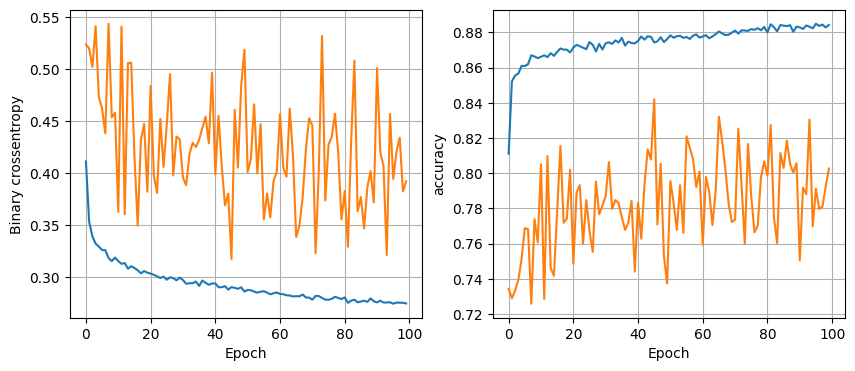

In [ ]:
plot_history(history)

In [ ]:
def train_model(x_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
  nn_model = tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation='relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])

  nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
  history = nn_model.fit(
    x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2
  )
  return nn_model, history

In [ ]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 100

for num_nodes in [16, 32, 64]:
  for dropout_prob in [0, 0.2]:
    for lr in [0.01, 0.005, 0.001]:
      for batch_size in [32, 64, 128]:
        print(f"{num_nodes} nodes, dropout {dropout_prob}, lr {lr}, batch size {batch_size}")

        # Train the model
        model, history = train_model(x_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)

        # Uncomment if you want to plot history during training
        # plot_history(history)

        # Evaluate model (handling list or scalar return types safely)
        eval_result = model.evaluate(x_valid, y_valid)
        val_loss = eval_result[0] if isinstance(eval_result, (list, tuple)) else float(eval_result)

        # Update the best model if validation loss improves
        if val_loss < least_val_loss:
          least_val_loss = val_loss
          least_loss_model = model

16 nodes, dropout 0, lr 0.01, batch size 32
Epoch 1/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8226 - loss: 0.3991 - val_accuracy: 0.6493 - val_loss: 0.6993
Epoch 2/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8499 - loss: 0.3533 - val_accuracy: 0.7437 - val_loss: 0.5147
Epoch 3/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8582 - loss: 0.3374 - val_accuracy: 0.7261 - val_loss: 0.5348
Epoch 4/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8608 - loss: 0.3310 - val_accuracy: 0.7363 - val_loss: 0.4979
Epoch 5/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8624 - loss: 0.3283 - val_accuracy: 0.7671 - val_loss: 0.4443
Epoch 6/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8595 - loss: 0.3286 - val_accuracy: 0.7187 - val_loss: 0.5235
Epoch 7/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8620 - loss: 0.3256 - val_accuracy: 0.7546 - val_loss: 0.4255
Epoch 8/100
370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 